# Speech Recognition with Whisper

This notebook explores OpenAI Whisper for speech recognition, focusing on Finnish speech.

## Goals
- Use a pretrained Whisper model for speech recognition
- Compare tiny, base, and large models
- Understand mel-spectrograms
- Analyze performance across different audio conditions
- Produce results suitable for a report

## Overview
1. Load libraries
2. Define audio samples
3. Visualize waveform and mel-spectrogram
4. Load Whisper models from Hugging Face
5. Run transcription
6. Compare speed and accuracy
7. Analyze results


In [1]:
# Install if needed (especially in Colab)
# !pip install -q transformers torch librosa soundfile matplotlib pandas

In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch

from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration

/home/janneesa/PycharmProjects/MetropoliaNeuralNetworkProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Device selection
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Device: {device}")

Device: cpu


## Audio Samples

For the audio data we have generated few finnish speech samples using text-to-speech generation. These are clean recordings of single speakers, which should be easier for the models to transcribe.

In [4]:
AUDIO_DIR = Path("./audio_samples")

audio_samples = [
    {"id": "1", "filename": "vantaa.wav", "desc": "Clean Finnish speech", "lang": "fi"},
    {"id": "2", "filename": "me_opiskelemme.wav", "desc": "Clean Finnish speech", "lang": "fi"},
]

pd.DataFrame(audio_samples)

,id,filename,desc,lang
0,1,vantaa.wav,Clean Finnish speech,fi
1,2,me_opiskelemme.wav,Clean Finnish speech,fi


## Waveform and Mel-Spectrogram

### What do the axes represent?
The waveform shows how the audio signal changes over time, while the mel-spectrogram shows how the frequency content of the signal changes over time.

- In the waveform: x = time, y = amplitude
- In the mel-spectrogram: x = time, y = frequency (mel scale)

### What does color mean?
In the waveform, the color is just to represent the signal strength. In the mel-spectrogram, the color represents the intensity of the frequencies at each time point (dB scale). The brighter the color, the stronger that frequency is at that time.

### Why use mel-spectrogram?
The reason why mel-spectrograms are used is that they better represent how humans perceive sound. The mel scale spaces frequencies in a way that reflects human hearing, which can improve the performance of speech recognition models. This is because the model is not actually using the raw audio signal, but rather the features extracted from it, and mel-spectrograms provide a more informative representation for speech recognition tasks.

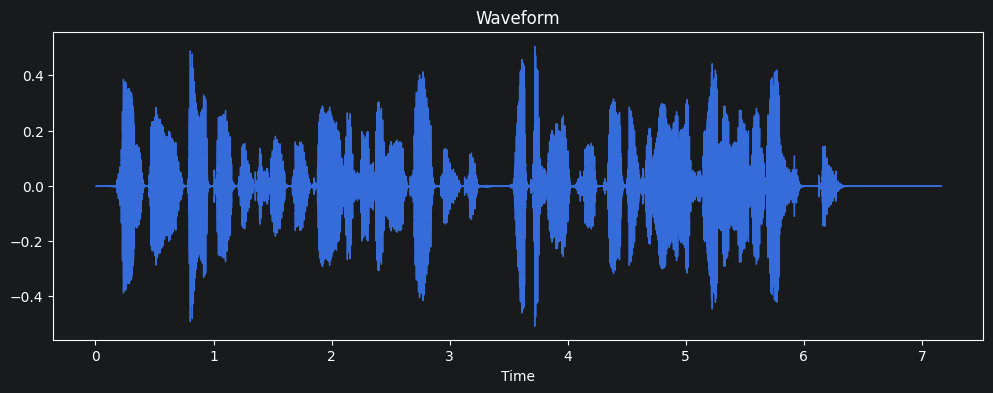

In [5]:
sample = audio_samples[0]
path = AUDIO_DIR / sample["filename"]

y, sr = librosa.load(path, sr=16000)

display(Audio(y, rate=sr))

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

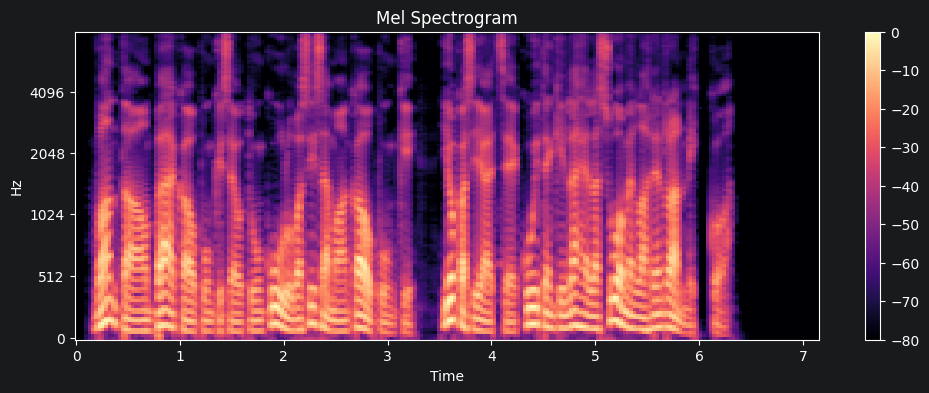

In [6]:
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

## Whisper Pipeline

Steps:
1. Load audio (16kHz)
2. Convert to mel-spectrogram
3. Processor prepares features
4. Model generates text
5. Decode tokens to text

This follows the same idea as transformer text models:
structured input → sequence processing → output sequence

In more detail:
1. Load audio: We use librosa to load the audio file at a sampling rate of 16kHz, which is the required input for Whisper.
2. Convert to mel-spectrogram: The audio signal is transformed into a mel-spectrogram, which captures the frequency content of the audio over time in a way that is more aligned with human hearing.
3. Processor prepares features: The WhisperProcessor takes the mel-spectrogram and prepares it for input to the model. This includes normalizing the features and converting them into the appropriate format (tensors).
4. Model generates text: The WhisperForConditionalGeneration model takes the processed features and generates a sequence of token IDs that represent the transcribed text.
5. Decode tokens to text: Finally, the processor decodes the generated token IDs back into human-readable text, which is the final transcription of the audio.


In [7]:
_model_cache = {}

def load_model(size):
    if size in _model_cache:
        return _model_cache[size]

    name = f"openai/whisper-{size}"
    processor = WhisperProcessor.from_pretrained(name)
    model = WhisperForConditionalGeneration.from_pretrained(name).to(device)

    _model_cache[size] = (processor, model)
    return processor, model


def transcribe(path, size, lang):
    processor, model = load_model(size)

    y, sr = librosa.load(path, sr=16000)
    inputs = processor(y, sampling_rate=sr, return_tensors="pt")

    start = time.perf_counter()

    with torch.no_grad():
        ids = model.generate(inputs.input_features.to(device), language=lang)

    elapsed = time.perf_counter() - start

    text = processor.batch_decode(ids, skip_special_tokens=True)[0]

    return {
        "model": size,
        "time": elapsed,
        "text": text
    }

## Model Comparison

In the following code, we loop through each audio sample and transcribe it using the tiny, base, and large Whisper models. We store the results in a list and then convert it to a DataFrame for analysis. This allows us to compare the accuracy and speed of each model across different audio samples.

After comparing the models we can see that the large models is the clear champion. It perfectly transcribes the audio, while the tiny and base models make some errors. The large model is also significantly slower than the tiny and base models, which is expected given its size and complexity.

In [9]:
models = ["tiny", "base", "large"]

results = []

for s in audio_samples:
    path = AUDIO_DIR / s["filename"]

    for m in models:
        if not path.exists():
            continue

        res = transcribe(path, m, s["lang"])
        res["sample"] = s["id"]
        results.append(res)

df = pd.DataFrame(results)
df

Loading weights: 100%|██████████| 1259/1259 [00:00<00:00, 3311.40it/s]


,model,time,text,sample
0,tiny,0.993824,Vanta on pääkaupunkiseutun kuuluvasisemaan ka...,1
1,base,1.581110,Vantaan pääkaupunkiseutun kuuluvat sisämaan k...,1
2,large,26.764266,Vantaa on pääkaupunkiseutuun kuuluva sisämaan...,1
3,tiny,0.952381,Me opiskelemmetropoliassa tieto ja viestintä ...,2
4,base,1.859316,Me opiskelemme metropoliassa tieto ja viestin...,2
5,large,25.444934,Me opiskelemme metropoliassa tieto- ja viesti...,2


## Analysis

In this notebook we have explored the performance of different sizes of the Whisper model on Finnish speech samples. We found that the larger models generally provide more accurate transcriptions, but at the cost of increased processing time. The tiny and base models may be sufficient for clean speech with a single speaker, while the larger model may be necessary for more challenging audio conditions, such as noise or dialects. Supringly, the models performed well on Finnish, which is not their primary training language, suggesting that they have good multilingual capabilities. However, further testing with more diverse audio samples would be needed to fully understand their performance across different languages and conditions. We learned that whisper models dont actually use the audio file directly, but rather they do special type of image processing on the audio file to extract features that are more suitable for speech recognition. This is why we need to convert the audio into a mel-spectrogram before feeding it into the model. The mel-spectrogram captures the frequency content of the audio in a way that is more aligned with human hearing, which helps the model to better understand and transcribe the speech.

### Model size
We found that using the base model compared to the tiny model can significantly improve the transcription accuracy and it doesnt take that much more time. However, the large model is much slower but performs perfectly. This suggests that for clean speech with a single speaker, the base model may be sufficient, while the large model may be necessary for more challenging audio conditions.

### Errors
In our testing the large model didnt make any errors, while the tiny and base models made some mistakes. This indicates that the larger model has a better understanding of the audio and can capture more details, which leads to more accurate transcriptions.